# Crop Pest ResNet18 Classifier
Transfer learning from ImageNet-pretrained ResNet18 on YOLO-cropped pest images

In [46]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path().resolve().parent))

import os
import time
from tqdm import tqdm

import numpy as np
import torch
import torchvision
from torchvision import transforms, datasets
from torch import nn, optim
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report

from shared import (
    resolve_paths, set_seed, get_device,
    build_classification_dataset, evaluate,
    plot_confusion_matrix, plot_training_curves,
    save_metrics_csv, save_classification_report,
)

PROJECT_ROOT, DATA_ROOT, OUT_ROOT = resolve_paths()

PROJECT_ROOT: f:\github\agro-pest
DATA_ROOT:    f:\github\agro-pest\archive
OUT_ROOT:     f:\github\agro-pest\runs
Data exists:  True


In [47]:
CONFIG = {
    "YOLO_ROOT": DATA_ROOT,
    "OUT_ROOT": OUT_ROOT,

    "CLASS_NAMES": [
        "Ants", "Bees", "Beetles", "Caterpillars", "Earthworms", "Earwigs",
        "Grasshoppers", "Moths", "Slugs", "Snails", "Wasps", "Weevils",
    ],

    "CROP_MARGIN_RATIO": 0.07,
    "MIN_CROP_SIZE": 10,

    "IMG_SIZE": 256,
    "BATCH_SIZE": 64,
    "NUM_WORKERS": 4,
    "EPOCHS": 30,
    "LR": 4e-4,
    "WEIGHT_DECAY": 1e-4,
    "SEED": 42,
    "SAVE_BEST_METRIC": "macro_f1",
    "FREEZE_BACKBONE": False,
}

cfg = CONFIG

In [48]:
def get_dataloaders(ds_root, img_size=256, batch=64, workers=4):
    norm_mean = [0.485, 0.456, 0.406]
    norm_std = [0.229, 0.224, 0.225]

    tf_train = transforms.Compose([
        transforms.RandomResizedCrop(img_size, scale=(0.95, 1.0)),
        transforms.RandomRotation(10),
        transforms.RandomHorizontalFlip(),
        transforms.ColorJitter(0.2, 0.2, 0.2, 0.1),
        transforms.ToTensor(),
        transforms.Normalize(norm_mean, norm_std),
    ])
    tf_eval = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        transforms.Normalize(norm_mean, norm_std),
    ])

    train_ds = datasets.ImageFolder(str(Path(ds_root) / "train"), transform=tf_train)
    valid_ds = datasets.ImageFolder(str(Path(ds_root) / "valid"), transform=tf_eval)
    test_ds = datasets.ImageFolder(str(Path(ds_root) / "test"), transform=tf_eval)

    train_dl = DataLoader(train_ds, batch_size=batch, shuffle=True, num_workers=workers, pin_memory=True)
    valid_dl = DataLoader(valid_ds, batch_size=batch, shuffle=False, num_workers=workers, pin_memory=True)
    test_dl = DataLoader(test_ds, batch_size=batch, shuffle=False, num_workers=workers, pin_memory=True)
    return train_dl, valid_dl, test_dl, train_ds.classes

In [49]:
def create_model(num_classes, freeze_backbone=False):
    model = torchvision.models.resnet18(
        weights=torchvision.models.ResNet18_Weights.IMAGENET1K_V1
    )
    if freeze_backbone:
        for p in model.parameters():
            p.requires_grad = False
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)
    return model

In [50]:
set_seed(cfg["SEED"])
device = get_device()
print(f"[device] {device}")

ds_cls_root = build_classification_dataset(
    yolo_root=cfg["YOLO_ROOT"],
    out_root=cfg["OUT_ROOT"],
    class_names=cfg["CLASS_NAMES"],
    margin_ratio=cfg["CROP_MARGIN_RATIO"],
    min_crop=cfg["MIN_CROP_SIZE"],
)

[device] cuda
[build] train: 11502 images


Build train: 100%|██████████| 11502/11502 [03:29<00:00, 54.90it/s] 


[build] valid: 1095 images


Build valid: 100%|██████████| 1095/1095 [00:11<00:00, 92.40it/s] 


[build] test: 546 images


Build test: 100%|██████████| 546/546 [00:02<00:00, 187.55it/s]

[build] Cropped classification dataset at: f:\github\agro-pest\runs\dataset_cls
  train: 15271 samples
  valid: 1341 samples
  test: 689 samples


In [51]:
train_dl, valid_dl, test_dl, classes = get_dataloaders(
    ds_cls_root, img_size=cfg["IMG_SIZE"], batch=cfg["BATCH_SIZE"], workers=cfg["NUM_WORKERS"]
)
print(f"[data] classes: {classes}")

model = create_model(num_classes=len(cfg["CLASS_NAMES"]), freeze_backbone=cfg["FREEZE_BACKBONE"]).to(device)
params = [p for p in model.parameters() if p.requires_grad]
optimizer = optim.AdamW(params, lr=cfg["LR"], weight_decay=cfg["WEIGHT_DECAY"])
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=cfg["EPOCHS"])
criterion = nn.CrossEntropyLoss()

best_metric = -1.0
save_dir = Path(cfg["OUT_ROOT"]) / f"resnet18_run_{time.strftime('%Y%m%d_%H%M%S')}"
save_dir.mkdir(parents=True, exist_ok=True)
best_w_path = save_dir / "best_resnet18.pth"

train_losses, valid_accs, valid_f1s = [], [], []

for epoch in range(1, cfg["EPOCHS"] + 1):
    model.train()
    running_loss = 0.0
    t0 = time.perf_counter()
    pbar = tqdm(train_dl, desc=f"Epoch {epoch:02d}/{cfg['EPOCHS']}", leave=False)
    for x, y in pbar:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * x.size(0)
        pbar.set_postfix(loss=f"{loss.item():.4f}")
    scheduler.step()
    train_loss = running_loss / len(train_dl.dataset)

    acc, prec, rec, f1, cm, _, _ = evaluate(model, valid_dl, device, desc="Valid")
    metric = f1 if cfg["SAVE_BEST_METRIC"] == "macro_f1" else acc
    dt = time.perf_counter() - t0
    print(
        f"[epoch {epoch:02d}] {dt:.1f}s | lr={scheduler.get_last_lr()[0]:.2e} "
        f"| train_loss={train_loss:.4f} | valid_acc={acc:.4f} valid_f1={f1:.4f}"
    )

    train_losses.append(train_loss)
    valid_accs.append(acc)
    valid_f1s.append(f1)

    if metric > best_metric:
        best_metric = metric
        torch.save(model.state_dict(), best_w_path)
        print(f"  -> saved best to {best_w_path}")

[data] classes: ['Ants', 'Bees', 'Beetles', 'Caterpillars', 'Earthworms', 'Earwigs', 'Grasshoppers', 'Moths', 'Slugs', 'Snails', 'Wasps', 'Weevils']
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\manafeng-local/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:02<00:00, 20.4MB/s]


[epoch 01] 57.5s | lr=3.99e-04 | train_loss=0.6306 | valid_acc=0.7636 valid_f1=0.7590
  -> saved best to f:\github\agro-pest\runs\resnet18_run_20260429_072702\best_resnet18.pth


[epoch 02] 53.5s | lr=3.96e-04 | train_loss=0.3438 | valid_acc=0.8218 valid_f1=0.8153
  -> saved best to f:\github\agro-pest\runs\resnet18_run_20260429_072702\best_resnet18.pth


[epoch 03] 54.1s | lr=3.90e-04 | train_loss=0.2437 | valid_acc=0.8180 valid_f1=0.8083


...

[epoch 26] 48.8s | lr=1.73e-05 | train_loss=0.0011 | valid_acc=0.8688 valid_f1=0.8629


[epoch 27] 49.6s | lr=9.79e-06 | train_loss=0.0008 | valid_acc=0.8777 valid_f1=0.8719
  -> saved best to f:\github\agro-pest\runs\resnet18_run_20260429_072702\best_resnet18.pth


[epoch 28] 49.7s | lr=4.37e-06 | train_loss=0.0009 | valid_acc=0.8732 valid_f1=0.8677


[epoch 29] 49.2s | lr=1.10e-06 | train_loss=0.0008 | valid_acc=0.8762 valid_f1=0.8704


[epoch 30] 49.4s | lr=0.00e+00 | train_loss=0.0008 | valid_acc=0.8770 valid_f1=0.8715


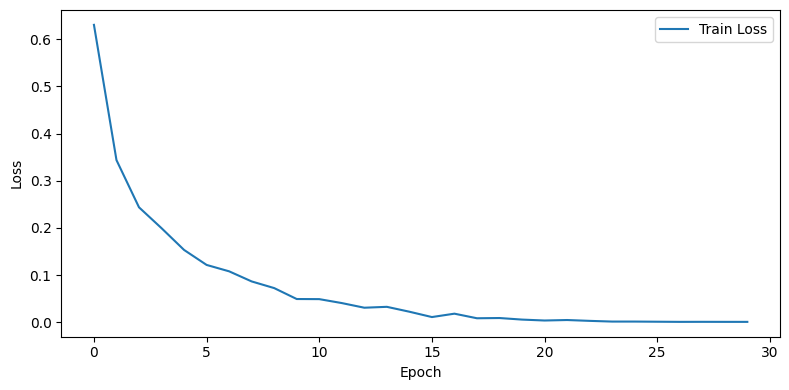

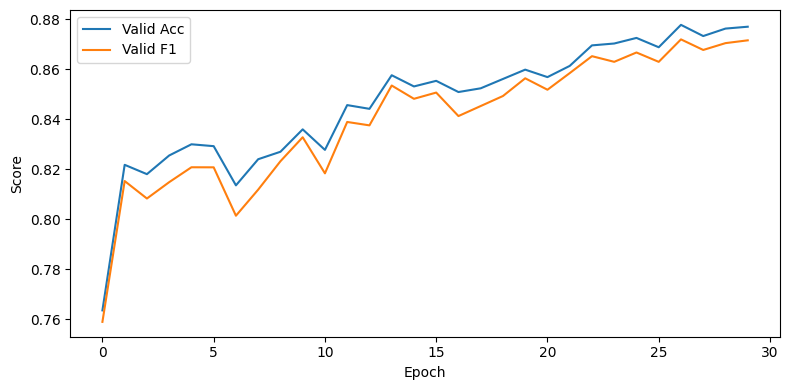

In [52]:
plot_training_curves(train_losses, valid_accs, valid_f1s, save_dir)

Valid: acc=0.8777 prec=0.8812 rec=0.8667 f1=0.8719
Test:  acc=0.8636 prec=0.8682 rec=0.8634 f1=0.8635

Confusion Matrix (Valid):


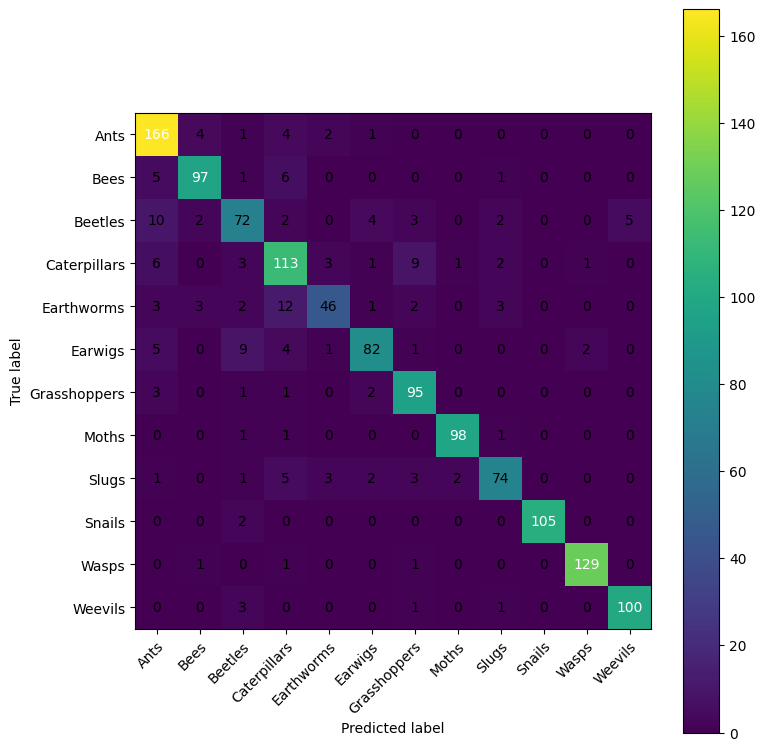


Confusion Matrix (Test):


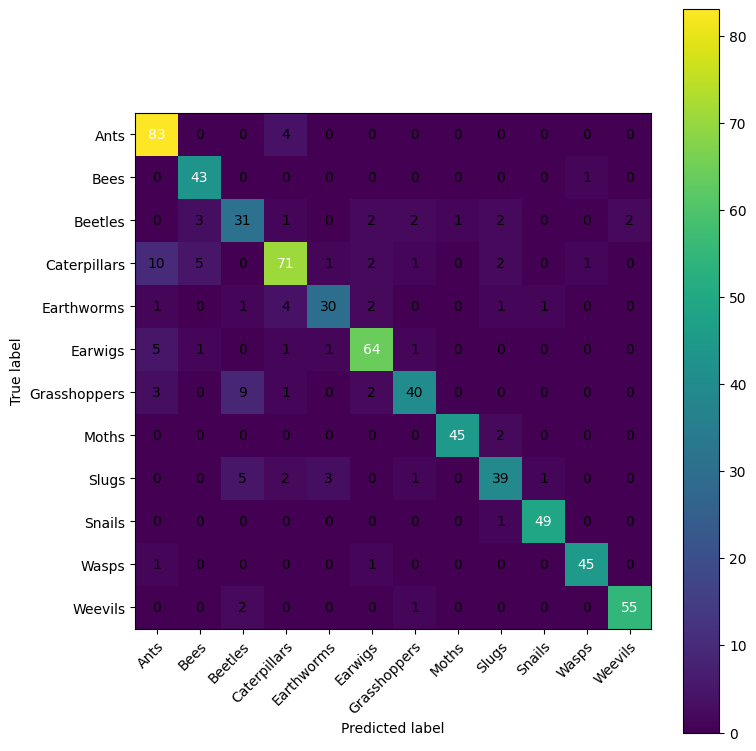


Classification Report (Test):
              precision    recall  f1-score   support

        Ants     0.8058    0.9540    0.8737        87
        Bees     0.8269    0.9773    0.8958        44
     Beetles     0.6458    0.7045    0.6739        44
Caterpillars     0.8452    0.7634    0.8023        93
  Earthworms     0.8571    0.7500    0.8000        40
     Earwigs     0.8767    0.8767    0.8767        73
Grasshoppers     0.8696    0.7273    0.7921        55
       Moths     0.9783    0.9574    0.9677        47
       Slugs     0.8298    0.7647    0.7959        51
      Snails     0.9608    0.9800    0.9703        50
       Wasps     0.9574    0.9574    0.9574        47
     Weevils     0.9649    0.9483    0.9565        58

    accuracy                         0.8636       689
   macro avg     0.8682    0.8634    0.8635       689
weighted avg     0.8664    0.8636    0.8626       689


=== DONE (ResNet18) ===
Artifacts saved in: f:\github\agro-pest\runs\resnet18_run_20260429_072702
  -

In [53]:
model.load_state_dict(torch.load(best_w_path, map_location=device, weights_only=True))

acc_v, prec_v, rec_v, f1_v, cm_v, _, _ = evaluate(model, valid_dl, device, desc="Valid")
acc_t, prec_t, rec_t, f1_t, cm_t, y_true_t, y_pred_t = evaluate(model, test_dl, device, desc="Test")

print(f"Valid: acc={acc_v:.4f} prec={prec_v:.4f} rec={rec_v:.4f} f1={f1_v:.4f}")
print(f"Test:  acc={acc_t:.4f} prec={prec_t:.4f} rec={rec_t:.4f} f1={f1_t:.4f}")

print("\nConfusion Matrix (Valid):")
plot_confusion_matrix(cm_v, classes, save_dir / "cm_valid.png")
print("\nConfusion Matrix (Test):")
plot_confusion_matrix(cm_t, classes, save_dir / "cm_test.png")

print("\nClassification Report (Test):")
print(classification_report(y_true_t, y_pred_t, target_names=classes, digits=4))

metrics_csv = save_metrics_csv(save_dir, acc_v, prec_v, rec_v, f1_v, acc_t, prec_t, rec_t, f1_t)
report_txt = save_classification_report(save_dir, y_true_t, y_pred_t, classes)

print("\n=== DONE (ResNet18) ===")
print(f"Artifacts saved in: {save_dir}")
print(f"  - Best weights: {best_w_path}")
print(f"  - Valid CM:     {save_dir / 'cm_valid.png'}")
print(f"  - Test  CM:     {save_dir / 'cm_test.png'}")
print(f"  - Metrics :     {metrics_csv}")
print(f"  - Report  :     {report_txt}")